## Purpose within the customer-lifetime-value workflow

Customer lifetime value (CLV) is the value a customer is expected to generate after the point at which the business must make a decision. In other words, CLV is the total expected expenditure by a customer for a future time $H$, where $H$ can be number of days, months or years under discussion. For a horizon of $H$ days, a useful decomposition is

$$\operatorname{E}(CLV_i \mid \mathcal{H}_i, H) = \operatorname{E}(X_i(H) \mid \mathcal{H}_i) 	\times \operatorname{E}(M_i \mid \mathcal{H}_i),$$

where $\mathcal{H}_i$ is customer $i$'s calibration history, $X_i(H)$ is the number of future baskets/orders, and $M_i$ is the average monetary value of each order. This notebook estimates the first term: the expected number of future orders. It also estimates the probability that a customer remains active. `03_CLV.ipynb` estimates the second term with a Gamma-Gamma model and combines the two outputs. The factorisation relies on the usual working assumption that a customer's transaction frequency and order value are independent after conditioning on their latent characteristics; the later notebook explicitly examines this assumption.

A customer who has not bought recently may be inactive, or may simply be between purchases. The Pareto/NBD model addresses this uncertainty probabilistically from the customer's observed frequency, recency, and age. 

A churned customer is a customer who has permanently become inactive—in Pareto/NBD terminology, the customer's latent dropout event has occurred: the customer has stopped purchasing from the retailer permanently, even though that dropout event is not directly observed in the transaction data. This is different from making no purchase during the finite 369-day holdout period. 

The Pareto/NBD model was originally developed by Schmittlein, Morrison, and Colombo (1987) in [*Counting Your Customers: Who Are They and What Will They Do Next?*](https://doi.org/10.1287/mnsc.33.1.1). Its integration with the Gamma-Gamma monetary-value model for CLV was developed by Fader, Hardie, and Lee (2005) in [*RFM and CLV: Using Iso-Value Curves for Customer Base Analysis*](https://doi.org/10.1509/jmkr.2005.42.4.415).

## Summary of purchase-frequency results

The Pareto/NBD model should be read as a probabilistic purchase-frequency model, not as a tool that definitively finds every churned customer. In a non-contractual retail setting, the data do not contain an observed cancellation event. The model therefore assigns each customer a probability of latent permanent dropout (churn), a probability of making no purchase in the 369-day holdout horizon, and an expected number of future purchases.

The holdout evaluation shows that this distinction matters. At a fixed $0.5$ churn cutoff, the model flags only **11 of 4,253** customers as churned. Of the **1,557** customers with no holdout purchase, only **8** are flagged, giving a recall of approximately **0.5%**. The threshold is therefore not useful for identifying individual zero-purchase customers. However, the continuous churn probabilities achieve a ROC AUC of **0.7483**, meaning that the model ranks a randomly selected zero-purchase customer above a randomly selected purchaser about **74.8%** of the time.

The probabilistic totals give a more appropriate interpretation. Summing $1-p_{alive,i}$ across customers produces **103.74 expected churned customers**: for example, 100 customers who each have a churn probability of 0.05 contribute five expected churns, without identifying which five customers churned. Summing $p_{0,i}=\Pr[X_i(H)=0 \mid \mathcal{H}_i]$ gives **1,043.94 expected zero-purchase customers**, compared with **1,557 observed**. The difference between these two model totals represents customers expected to remain active but make no purchase during the holdout period; numerically, this contribution is approximately **940.20** customers ($1{,}043.94-103.74$).

The figure *PyMC Pareto/NBD: Churn vs Zero-Purchase Probability* supports this distinction. Across calibration-frequency groups, the predicted zero-purchase curve follows the observed zero-purchase pattern much more closely than the permanent-churn curve. This shows why temporary inactivity should be included when explaining zero holdout purchases: Pareto/NBD separates latent permanent churn from the possibility that an active customer simply makes no purchase during the 369-day window.

For purchase frequency, the model predicts **17,025** holdout purchases versus **12,493** observed purchases. This overpredicts the total count by about **36%**, so the absolute volume forecast is optimistic. Even so, the customer-level association is strong enough for prioritisation work, with Pearson $r=0.838$ and Spearman $\rho=0.592$ between predicted and observed purchase counts. The practical conclusion is that Pareto/NBD is best used here for relative activity ranking and group-level purchase-risk estimation, rather than for exact individual churn labels.

## Inputs, outputs, and notebook sequence

Run `00_Create_case_study_data.ipynb` and `01_Cleaning.ipynb` before this notebook. The cleaning workflow creates `data/working_data/calib_order.csv` and `data/working_data/holdout_order.csv`: each row is one cleaned customer-day order, with `Customer_ID`, `order_id`, `order_date`, `total_amount`, and `number_of_items`. The calibration file supplies the purchase history used to estimate the Pareto/NBD parameters and each customer's RFM summary: frequency, recency, and observed customer age. The holdout file is kept out of estimation and is used only to ask whether forecasts made from calibration history remain accurate over the following 369 days.

The notebook writes `data/working_data/lifetimes.csv` for `03_CLV.ipynb`. It contains one row per modelled customer, including the RFM variables, the estimated probability of being alive, and `predicted_transactions`, the expected number of orders in the 369-day holdout horizon. The evaluation reports both probability-based diagnostics, whether predicted no-purchase risk agrees with observed no-purchase behaviour, and count-based diagnostics, whether the expected number of future purchases agrees with realised holdout orders.

The observed holdout results give a useful assessment. Across **4,253** customers, the model predicts **17,025** purchases, compared with **12,493** observed, so it overstates the total volume by about **36%**. Its customer-level purchase-count ranking is nevertheless informative (Pearson $r=0.838$; Spearman $ho=0.592$): customers predicted to purchase more generally do purchase more. The risk figures tell the same nuanced story. A $0.5$ churn cutoff identifies only **8** of **1,557** customers with no holdout purchase, but the model-implied no-purchase probability follows the observed no-purchase pattern across frequency and recency groups. Thus the fitted model is more credible for estimating group-level purchase risk and relative customer activity than for exact individual churn labels or exact aggregate purchase volume.

## Pareto/NBD Model: Behavioural Story and Mathematical Specification

**Pareto/NBD is used because the retailer operates in a non-contractual setting: customers can stop buying without ever announcing that they have churned.** A simple rule based on the last purchase date would confuse genuinely inactive customers with infrequent but still active customers. Pareto/NBD is designed for exactly this situation. It uses each customer's frequency, recency, and age to estimate both future purchase counts and the probability of latent dropout, while allowing customers to differ in their natural purchase rates and dropout propensities. This makes it more appropriate than a purely descriptive frequency table or a supervised churn classifier when no true churn label is observed.

The **Pareto/NBD (Pareto/Negative Binomial Distribution)** model is a probabilistic *buy-'til-you-die* model designed to describe and predict customer purchasing behaviour in **non-contractual settings**. In such settings, customers do not explicitly cancel a subscription or terminate a relationship, so their true churn status is not directly observed. A customer who has not purchased for a long period may have permanently become inactive, or may simply be an infrequent buyer who remains active.

Pareto/NBD addresses this uncertainty by modelling two separate behavioural processes for each customer:

* **Purchase process:** While a customer is active, purchases occur randomly at a customer-specific rate.
* **Dropout process:** At some unobserved point in time, the customer may permanently become inactive.

The model therefore does not automatically classify a customer as churned simply because they have stopped purchasing. Instead, it uses the customer's observed transaction history to estimate the probability that the customer is still active and to predict their future purchasing behaviour.

---


### Model Assumptions

The standard Pareto/NBD model is based on the following assumptions:

* **The individual purchase rate is constant over time.** Conditional on $\lambda_i$, the customer's underlying purchasing intensity does not change during their active lifetime **(Poisson process)**.

* **Dropout follows an exponential process conditional on the customer's dropout rate.** Each customer has an individual dropout (**churn**) rate $\mu_i$, which remains constant over their lifetime.

* **Purchase rate and dropout rate are independent.** In the standard Pareto/NBD specification, $\lambda_i$ and $\mu_i$ are assumed to be independently distributed across customers.

These assumptions allow Pareto/NBD to infer latent customer activity from transaction timing alone.

---



### Formal Description of the Model

**Observed Customer History:** For each customer $i$, Pareto/NBD summarizes the observed transaction history using three quantities:
$
(x_i,t_{x,i},T_i),
$,
where:

* $x_i$ = number of **repeat purchases** made by customer $i$ during the observation period;
* $t_{x,i}$ = time between the customer's first purchase and their most recent observed purchase;
* $T_i$ = total time between the customer's first purchase and the end of the observation period.


**Individual-Level Purchase Process:**
While customer $i$ remains active, purchases follow a Poisson process with customer-specific transaction rate $\lambda_i$.
For an interval of length $t$,

$$
X_i(t)\mid\lambda_i
\sim
\operatorname{Poisson}(\lambda_i t),
$$

where $X_i(t)$ denotes the number of purchases made by customer $i$ during an interval of length $t$.
The corresponding probability of observing exactly $x$ purchases is

$$
\Pr\left(X_i(t)=x\mid\lambda_i\right)=
\frac{(\lambda_i t)^x e^{-\lambda_i t}}{x!}.
$$



Here:

* $X_i(t)$ = number of purchases during an interval of length $t$;
* $x$ = a particular observed number of purchases;
* $t$ = length of the time interval;
* $\lambda_i$ = latent transaction rate of customer $i$.


Conditional on $\lambda_i$, the expected number of purchases over an interval of length $t$ is

$$
E[X_i(t)\mid\lambda_i]=
\lambda_i t.
$$

Therefore, $\lambda_i$ can be interpreted as the customer's underlying purchasing intensity. A larger $\lambda_i$ corresponds to a customer who tends to purchase more frequently, whereas a smaller $\lambda_i$ corresponds to a naturally infrequent purchaser.


**Heterogeneity in Purchase Rates:**
Pareto/NBD does not assume that every customer has the same purchasing frequency. Instead, the individual transaction rates are assumed to vary across the customer population according to a Gamma distribution:

$$
\lambda_i
\sim
\operatorname{Gamma}(r,\alpha).
$$

Using the shape-rate parameterization, its density is

$$
f(\lambda_i)=
\frac{\alpha^r}{\Gamma(r)}
\lambda_i^{r-1}
e^{-\alpha\lambda_i},
\qquad
\lambda_i>0,
$$

where:

* $r>0$ = shape parameter governing the distribution of purchase rates;
* $\alpha>0$ = rate parameter governing the scale of purchase rates;
* $\Gamma(\cdot)$ = Gamma function.

Under this parameterization, $E[\lambda_i]=
\frac{r}{\alpha},$
and
$
\operatorname{Var}(\lambda_i)=
\frac{r}{\alpha^2}.
$
The parameters $(r,\alpha)$ therefore describe **population-level heterogeneity in purchasing intensity**.

The combination of a Poisson purchase process at the individual level and Gamma-distributed purchase rates across customers produces a negative-binomial distribution for purchase counts at the population level. This Gamma-Poisson mixture is the source of the **NBD** component of the name Pareto/NBD.


**Latent Customer Dropout Process:**
Purchasing continues only while the customer remains active.
Let $\tau_i$ denote the unobserved lifetime of customer $i$, measured from the beginning of the customer relationship until permanent dropout.

Conditional on customer-specific dropout rate $\mu_i$, the lifetime follows an exponential distribution:
$\tau_i\mid\mu_i
\sim
\operatorname{Exponential}(\mu_i).
$
The probability that customer $i$ remains active beyond time $t$ is therefore
$
\Pr(\tau_i>t\mid\mu_i)=
e^{-\mu_i t}.
$
Equivalently, the probability that the customer has dropped out by time $t$ is
$
\Pr(\tau_i\leq t\mid\mu_i)=
1-e^{-\mu_i t}.
$
Here:

* $\tau_i$ = latent lifetime of customer $i$;
* $\mu_i$ = latent dropout rate of customer $i$;
* $t$ = elapsed time since the beginning of the customer relationship.

A larger $\mu_i$ corresponds to a customer with a greater instantaneous tendency to become inactive, whereas a smaller $\mu_i$ corresponds to a customer who tends to remain active for longer.
Conditional on $\mu_i$, expected customer lifetime is
$
E[\tau_i\mid\mu_i]=
\frac{1}{\mu_i}.
$

**Heterogeneity in Dropout Rates:**
Just as purchasing frequency differs across customers, dropout propensity is also allowed to vary across the customer population.

Pareto/NBD assumes
$
\mu_i
\sim
\operatorname{Gamma}(s,\beta).
$

Using the shape-rate parameterization, the density is
$
f(\mu_i)=
\frac{\beta^s}{\Gamma(s)}
\mu_i^{s-1}
e^{-\beta\mu_i},
\qquad
\mu_i>0,
$
where:

* $s>0$ = shape parameter governing heterogeneity in dropout propensity;
* $\beta>0$ = rate parameter governing the scale of dropout rates.

Under this parameterization,
$
E[\mu_i]=
\frac{s}{\beta},
$
and
$
\operatorname{Var}(\mu_i)=
\frac{s}{\beta^2}.
$
The parameters $(s,\beta)$ therefore describe **population-level heterogeneity in customer dropout propensity**.
Mixing exponential customer lifetimes over the Gamma distribution of $\mu_i$ produces a Pareto-type distribution of customer lifetimes at the population level. This is the source of the **Pareto** component of the name Pareto/NBD.

**The Four Population-Level Parameters:**
The complete Pareto/NBD model is characterized by four population-level parameters:
$
(r,\alpha,s,\beta).
$
Their roles can be summarized as
$
(r,\alpha)
\longrightarrow
\text{heterogeneity in purchase rates},
$
and
$
(s,\beta)
\longrightarrow
\text{heterogeneity in dropout rates}.
$
Importantly, $\lambda_i$ and $\mu_i$ are **customer-level latent variables**, whereas $r,\alpha,s,\beta$ are **population-level model parameters**.
The model does not estimate an unrestricted $\lambda_i$ and $\mu_i$ independently for every customer. Instead, it estimates the population distributions from which these individual behavioural tendencies are assumed to arise.

**Combining Purchasing and Dropout Behaviour:**
For an individual customer, purchasing behaviour depends on two unobserved quantities:
$
\lambda_i=
\text{customer's purchase rate},
$
and
$
\mu_i=
\text{customer's dropout rate}.
$
Neither quantity is directly observed.
Instead, Pareto/NBD observes the customer's transaction history
$
(x_i,t_{x,i},T_i)
$
and integrates over the possible values of $\lambda_i$ and $\mu_i$ according to their Gamma population distributions.

Conceptually, the customer-level likelihood is therefore obtained from
$
L_i(r,\alpha,s,\beta)=
\int_0^\infty
\int_0^\infty
L_i(\lambda_i,\mu_i\mid x_i,t_{x,i},T_i)
f(\lambda_i\mid r,\alpha)
f(\mu_i\mid s,\beta)
\,d\lambda_i\,d\mu_i.
$

After integrating out the latent customer-specific rates, the probability of the observed transaction history depends only on
$
(x_i,t_{x,i},T_i)
$
and the four population parameters
$
(r,\alpha,s,\beta).
$

This integration allows the model to learn about an individual customer's likely purchase and dropout behaviour while sharing information across the entire customer population.

The intermediate mathematical derivation is omitted here because the purpose is to specify and interpret the model rather than derive it from first principles.

**Pareto/NBD Likelihood:** For a customer with observed history $(x,t_x,T)$, the Pareto/NBD likelihood represents two mutually exclusive possibilities:

* the customer remains active through the end of the observation period $T$;
* the customer becomes inactive sometime after their most recent purchase at $t_x$ and before $T$.

A convenient representation is

$$
L(r,\alpha,s,\beta\mid x,t_x,T)=
A_1+A_2,
$$

where the first component corresponds to the customer remaining active through $T$,

$$
A_1=
\frac{\Gamma(r+x)}{\Gamma(r)}
\frac{\alpha^r}{(\alpha+T)^{r+x}}
\left(\frac{\beta}{\beta+T}\right)^s,
$$

and the second component accounts for the possibility that the customer dropped out between the most recent purchase and the end of the observation period:

$$
A_2=
\frac{\Gamma(r+x)}{\Gamma(r)}
\alpha^r\beta^s s
\int_{t_x}^{T}
\frac{1}
{(\alpha+\tau)^{r+x}(\beta+\tau)^{s+1}}
\,d\tau.
$$

The complete likelihood therefore combines evidence for both possible latent states rather than forcing every non-purchasing customer to be classified as inactive.
For a customer base containing $N$ customers, the overall likelihood is

$$
L(r,\alpha,s,\beta)=
\prod_{i=1}^{N}
L_i(r,\alpha,s,\beta).
$$

**Parameter Estimation:**
The population parameters
$
r,\alpha,s,\beta
$
are estimated from the observed transaction histories of the customer population.
Under maximum-likelihood estimation, the fitted parameters are

$$
(\hat r,\hat\alpha,\hat s,\hat\beta)=
\underset{r,\alpha,s,\beta}{\arg\max}
\sum_{i=1}^{N}
\log
L_i(r,\alpha,s,\beta).
$$

If maximum a posteriori (MAP) estimation is used, explicit prior distributions are additionally placed on the population parameters, and the objective becomes

$$
(\hat r,\hat\alpha,\hat s,\hat\beta)=
\underset{r,\alpha,s,\beta}{\arg\max}
\left[
\sum_{i=1}^{N}\log L_i
+
\log p(r,\alpha,s,\beta)
\right].
$$

It is important to distinguish these priors from the Gamma distributions assigned to $\lambda_i$ and $\mu_i$. The Gamma distributions
$
\lambda_i\sim\operatorname{Gamma}(r,\alpha)
$
and
$
\mu_i\sim\operatorname{Gamma}(s,\beta)
$
describe **heterogeneity among customers**. They are part of the Pareto/NBD behavioural model itself and are not, by themselves, priors on the population parameters $r,\alpha,s,\beta$.

**Posterior Probability That a Customer Is Alive:**
One of the most useful outputs of Pareto/NBD is the probability that a customer is still active at the end of the observation period.

For customer $i$,

$$
p_{\text{alive},i}=
\Pr
\left(
\tau_i>T_i
\mid
x_i,t_{x,i},T_i
\right).
$$

Using the two components of the customer likelihood,

$$
p_{\text{alive},i}=
\frac{A_{1,i}}
{A_{1,i}+A_{2,i}}.
$$

This is a **posterior probability**. The model begins with population-level assumptions about purchasing and dropout behaviour and updates its assessment after observing the customer's actual purchase frequency, recency, and exposure time.
A long period without purchasing does not automatically imply
$
p_{\text{alive},i}=0.
$
Instead, the importance of that inactivity depends on the customer's observed purchasing pattern.
For example, a long gap may be relatively normal for an infrequent customer but highly unusual for a historically frequent purchaser. Pareto/NBD incorporates this distinction when estimating the probability that each customer remains active.

**Model-Based Churn Probability:**
The probability that customer $i$ has already dropped out by the end of the observation period is the complement of the probability that the customer is alive:

$$
\Pr(\tau_i\leq T_i\mid x_i,t_{x,i},T_i)=
1-p_{\text{alive},i}.
$$

In this analysis, this quantity is stored as
pred_churn_prob = 1 - p_alive.
This should be interpreted specifically as the **Pareto/NBD-implied probability that the customer's latent permanent dropout event has already occurred**.
It is not the same as a conventional supervised churn-classification probability based on an externally observed churn label. In Pareto/NBD, churn is latent and is inferred probabilistically from transaction behaviour.

**Future Transaction Distribution:**
Pareto/NBD can also predict the number of transactions a customer will make during a future period.
Let $H$
denote the length of the future prediction horizon.
For customer $i$, the model evaluates

$$
\Pr
\left[
X_i(H)=n
\mid
x_i,t_{x,i},T_i
\right],
\qquad
n=0,1,2,\ldots
$$

where:

* $H$ = future prediction horizon;
* $X_i(H)$ = number of transactions customer $i$ makes during the future horizon;
* $n$ = a possible number of future transactions.

This distribution incorporates uncertainty about both how frequently the customer purchases while active and whether the customer remains active long enough to make those purchases.

**Expected Number of Future Transactions:**
The expected number of transactions during horizon $H$ is obtained from the future transaction-count distribution:

$$
E
\left[
X_i(H)
\mid
x_i,t_{x,i},T_i
\right]=
\sum_{n=0}^{\infty}
n
\Pr
\left[
X_i(H)=n
\mid
x_i,t_{x,i},T_i
\right].
$$

In this analysis, this quantity is stored as
`predicted_transactions'
so that
$$
\text{predicted\_transactions}_i=
E
\left[
X_i(H)
\mid
x_i,t_{x,i},T_i
\right].
$$

This prediction reflects both the customer's inferred purchasing intensity and the uncertainty about whether the customer remains active.
Consequently, two customers with similar historical purchase frequencies may receive different future transaction predictions if their recency patterns imply substantially different probabilities of still being active.

**Permanent Dropout vs. No Purchase During a Future Period:**
The future transaction distribution also provides the probability that a customer makes exactly zero purchases during the prediction horizon:

$$
p_{0,i}=
\Pr
\left[
X_i(H)=0
\mid
x_i,t_{x,i},T_i
\right].
$$

In this analysis, this quantity is stored as $p_{0,i}$ and represents the probability that the customer will make **no transaction during the finite future period $H$**.
Its complement,
$
1-p_{0,i},
$
is the probability that the customer makes **at least one purchase** during the prediction horizon:
$
\Pr[X_i(H)\geq1\mid\text{history}]=
1-p_{0,i}.
$



A central distinction in Pareto/NBD is that **permanent inactivity and temporary non-purchasing are not the same event**. The model-based dropout probability is
$
1-p_{\text{alive},i}=
\Pr
\left(
\tau_i\leq T_i
\mid
x_i,t_{x,i},T_i
\right).
$

This represents the probability that the customer's latent permanent dropout event has already occurred.

In contrast,
$
p_{0,i}=
\Pr
\left[
X_i(H)=0
\mid
x_i,t_{x,i},T_i
\right]
$
represents the probability that the customer makes no purchase during a **specific finite future horizon**.

These quantities answer different questions:

| Quantity             | Question answered                                                                                  |
| -------------------- | -------------------------------------------------------------------------------------------------- |
| $p_{\text{alive}}$   | What is the probability that the customer is still active?                                         |
| $1-p_{\text{alive}}$ | What is the probability that the customer has permanently dropped out?                             |
| $p_0$                | What is the probability that the customer makes no purchase during the next $H$ periods?           |
| $1-p_0$              | What is the probability that the customer makes at least one purchase during the next $H$ periods? |

A customer can therefore have a high probability of still being active while simultaneously having a substantial probability of making no purchase during the prediction period.

For example, consider a customer who historically purchases only once every several months. The model may infer that the customer is very likely still active,
$
p_{\text{alive}}\approx1,
$
while also assigning a relatively high probability of zero purchases during a short prediction horizon.

Therefore,
$
p_0
\neq
1-p_{\text{alive}}.
$

The first represents **finite-horizon purchasing behaviour**, whereas the second represents **latent permanent dropout**.
This distinction is particularly important in non-contractual businesses, where the absence of a recent transaction does not provide direct evidence that a customer relationship has ended.

---

### Summary of Model Inputs and Outputs

At the customer level, Pareto/NBD receives the observed transaction history
$
(x_i,t_{x,i},T_i).
$
Across the customer population, it estimates four parameters:
$
(r,\alpha,s,\beta).
$
These parameters characterize two latent behavioural processes:

$$
\underbrace{
\lambda_i\sim\operatorname{Gamma}(r,\alpha)
}_{\text{purchase behaviour}}, \quad \mbox{and} \quad
\underbrace{
\mu_i\sim\operatorname{Gamma}(s,\beta)
}_{\text{dropout behaviour}}.
$$

The model then produces customer-level predictions such as

$$
p_{\text{alive},i}=
\Pr(\tau_i>T_i\mid\text{history}),
\quad
\text{pred\_churn\_prob}_i=
1-p_{\text{alive},i},
\quad
\text{predicted\_transactions}_i=
E[X_i(H)\mid\text{history}],
$$

and

$$
p_{0,i}=
\Pr[X_i(H)=0\mid\text{history}].
$$

The overall modelling process can therefore be summarized as

$$
\boxed{
\text{Observed transaction history}
\longrightarrow
\text{Pareto/NBD behavioural model}
\longrightarrow
\begin{cases}
\text{probability customer is active},\\
\text{probability of latent dropout},\\
\text{expected future transactions},\\
\text{probability of no future purchase}.
\end{cases}
}
$$

### Notation Reference

| Symbol                   | Definition                                                                |
| ------------------------ | ------------------------------------------------------------------------- |
| $i$                      | Customer index                                                            |
| $x_i$                    | Number of repeat purchases observed for customer $i$                      |
| $t_{x,i}$                | Time from the first purchase to the most recent observed purchase         |
| $T_i$                    | Time from the first purchase to the end of the observation period         |
| $T_i-t_{x,i}$            | Time since the customer's most recent purchase                            |
| $t$                      | Generic time interval                                                     |
| $H$                      | Future prediction horizon                                                 |
| $X_i(t)$                 | Number of purchases made by customer $i$ during an interval of length $t$ |
| $X_i(H)$                 | Number of purchases during the future prediction horizon                  |
| $n$                      | A possible number of future purchases                                     |
| $\lambda_i$              | Latent purchase rate of customer $i$                                      |
| $\mu_i$                  | Latent dropout rate of customer $i$                                       |
| $\tau_i$                 | Latent lifetime/dropout time of customer $i$                              |
| $r$                      | Shape parameter of the population purchase-rate distribution              |
| $\alpha$                 | Rate parameter of the population purchase-rate distribution               |
| $s$                      | Shape parameter of the population dropout-rate distribution               |
| $\beta$                  | Rate parameter of the population dropout-rate distribution                |
| $\Gamma(\cdot)$          | Gamma function                                                            |
| $p_{\text{alive},i}$     | Posterior probability that customer $i$ is still active at $T_i$          |
| $1-p_{\text{alive},i}$   | Probability that customer $i$ has already permanently dropped out         |
| $p_{0,i}$                | Probability of zero purchases during future horizon $H$                   |
| `predicted_transactions` | Expected number of purchases during future horizon $H$                    |



### Variables used in this notebook

- **`customer_id` / `Customer_ID`** — the customer key used to link order histories, model summaries, and holdout outcomes.
- **`order_date`, `order_id`** — the time and identity of each cleaned customer-day order. These define chronology and prevent multiple product lines from being treated as multiple purchases.
- **`frequency` ($x_i$)** — the number of *repeat* purchases in calibration. Larger values generally provide stronger evidence of an active, high-rate customer.
- **`recency` ($t_{x,i}$)** — time from the customer's first purchase to their latest calibration purchase. Holding $T_i$ fixed, larger recency means a more recent last purchase.
- **`T` ($T_i$)** — customer age: time from first purchase to the end of calibration. It measures how long the customer has been observable.
- **`scaled_time` and `scaled_time2`** — de-seasonalised time coordinates created before RFM aggregation; they reduce calendar-time variation that would otherwise be attributed to customer behaviour.
- **`holdout_period` ($H=369$ days)** — the forecasting horizon shared by the model and the observed holdout evaluation.
- **`observed_purchases` and `Observed_zero_purchase`** — realised holdout outcomes used only for validation, not for fitting.

The model assumes that, conditional on $\lambda_i$ and $\mu_i$, transactions are independent, the purchase rate is time-invariant, dropout is permanent, and $\lambda_i$ is independent of $\mu_i$. These are strong but transparent assumptions. The diagnostic figures below test where the data support the model and where the assumptions are strained.


## Importing Libraries and data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import pymc as pm
import arviz as az
import pymc_marketing
from pymc_marketing.clv import ParetoNBDModel, BetaGeoModel
from pymc_marketing.clv.utils import rfm_summary

from pathlib import Path

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

from pymc_marketing.clv import ParetoNBDModel, rfm_summary
import inspect

from scipy.stats import pearsonr, spearmanr

from IPython.display import display, HTML


In [2]:
df_calibration = pd.read_csv('data/working_data/calib_order.csv')

df_calibration['order_date'] = pd.to_datetime(df_calibration['order_date'])

print('df_calibration')
df_calibration.info()

df_calibration
<class 'pandas.DataFrame'>
RangeIndex: 16363 entries, 0 to 16362
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer_ID      16363 non-null  int64         
 1   order_date       16363 non-null  datetime64[us]
 2   total_amount     16363 non-null  float64       
 3   number_of_items  16363 non-null  float64       
 4   Country          16363 non-null  str           
 5   order_id         16363 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 767.1 KB


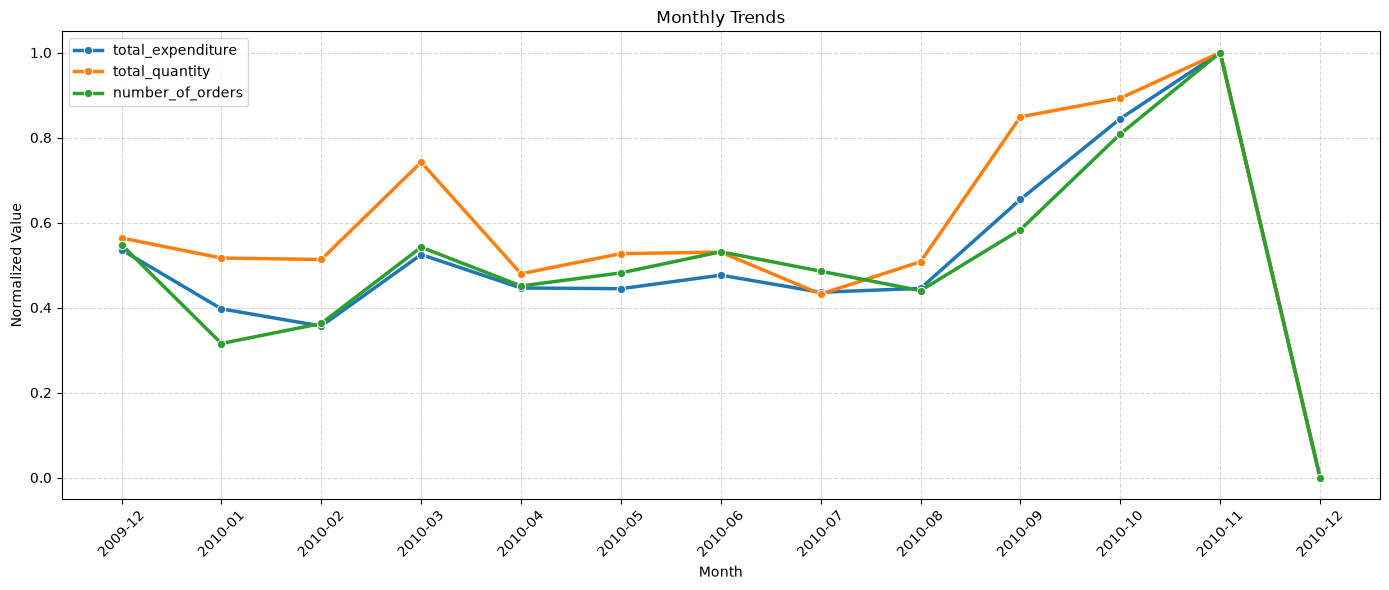

In [3]:
# monthly aggregation
monthly = (
    df_calibration
    .assign(month=df_calibration["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        total_expenditure=("total_amount", "sum"),
        total_quantity=("number_of_items", "sum"),
        number_of_orders=("order_id", "nunique")
    )
    .sort_values("month")
)

# add label for plotting
monthly["month_label"] = monthly["month"].dt.strftime("%Y-%m")

# Normalize the three metrics
plot_df = monthly.copy()

scaler = MinMaxScaler()
plot_df[["total_expenditure", "total_quantity", "number_of_orders"]] = scaler.fit_transform(
    plot_df[["total_expenditure", "total_quantity", "number_of_orders"]]
)

# Convert to long format
plot_long = plot_df.melt(
    id_vars="month_label",
    value_vars=["total_expenditure", "total_quantity", "number_of_orders"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=plot_long,
    x="month_label",
    y="Value",
    hue="Metric",
    marker="o",
    linewidth=2.5
)

ax = plt.gca()
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.title("Monthly Trends")
plt.xlabel("Month")
plt.ylabel("Normalized Value")
plt.xticks(rotation=45)
plt.legend(title="")
plt.tight_layout()
plt.show()


<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Figure discussion — calendar-time variation and stationarity.</em></strong></div>

The monthly plot is a direct diagnostic of a central Pareto/NBD assumption: **the model assumes that a customer's purchase intensity $\lambda_i$ is constant over the time window under discussion**. At an aggregate level, after allowing for a stable customer composition, order count, quantity, and expenditure should therefore fluctuate permitted under ordinary sampling variation. The figure instead shows pronounced month-to-month movement in all three normalised series. The co-movement of orders, units, and revenue is particularly informative: it suggests a market-wide demand process—such as seasonal shopping, promotion, or changing product availability—rather than an isolated change in basket value.

This pattern indicates a **violation of the constant-purchase-rate assumption**, weakening a literal interpretation of the fitted $\lambda_i$. A customer who happened to purchase during a high-demand month may appear intrinsically more active than they really are, while a customer observed during a quiet month may appear less engaged. If left untreated, the model may overpredict after a demand peak and underpredict after a demand trough.

The next cell gives busy and quiet periods a more even role in the time scale. It keeps every order in the same chronological order, but spreads out periods with many orders and compresses periods with few orders before recency and customer age are calculated. No transactions are added, removed, or moved. The aim is simply to reduce the chance that a seasonal surge is mistaken for a customer being permanently more active. This adjustment cannot remove every effect of promotions, holidays, or changing demand, so the holdout results below are used to judge whether it helps.


In [4]:
# sort chronologically
df_calibration = df_calibration.sort_values(
    ["order_date", "Customer_ID", "order_id"]
).reset_index(drop=True)

n = len(df_calibration)

start_time = df_calibration["order_date"].min()
end_time = df_calibration["order_date"].max()

## time-warping / de-seasonalization step.
span_seconds = (end_time - start_time).total_seconds()

# rank-based scaled time in [0, 1]
if n == 1:
    df_calibration["scaled_u"] = 0.0
else:
    df_calibration["scaled_u"] = np.arange(n) / (n - 1)

# map to observed calendar span
df_calibration["scaled_time"] = start_time + pd.to_timedelta(
    df_calibration["scaled_u"] * span_seconds,
    unit="s"
)

df_calibration["scaled_time2"] = (
    df_calibration["order_date"]
    + (df_calibration["scaled_time"] - df_calibration["order_date"]) / 2
)

df_calibration.drop(columns=['scaled_u', 'order_date'], inplace=True)
df_calibration.info()

<class 'pandas.DataFrame'>
RangeIndex: 16363 entries, 0 to 16362
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer_ID      16363 non-null  int64         
 1   total_amount     16363 non-null  float64       
 2   number_of_items  16363 non-null  float64       
 3   Country          16363 non-null  str           
 4   order_id         16363 non-null  str           
 5   scaled_time      16363 non-null  datetime64[ns]
 6   scaled_time2     16363 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(1), str(2)
memory usage: 895.0 KB


## Fitting Pareto/NBD Using pymc marketing

In [5]:
summary_cal = rfm_summary(
    transactions=df_calibration,
    customer_id_col="Customer_ID",
    datetime_col="scaled_time",
    monetary_value_col="total_amount",
    observation_period_end=df_calibration["scaled_time"].max(),
    time_unit="D"
)

pareto_model = ParetoNBDModel(data=summary_cal)
pareto_model.fit(fit_method="map")

out = Path("pareto_nbd_fit.nc")
if out.exists():
    out.unlink()

pareto_model.save(out)

Output()

In [6]:
holdout_period = 369

summary_cal["predicted_transactions"] = (
    pareto_model.expected_purchases(
        data=summary_cal,
        future_t=holdout_period
    )
    .mean(("chain", "draw"))
    .values
)

summary_cal.to_csv('data/working_data/lifetimes.csv')

In [7]:
df_holdout = pd.read_csv('data/working_data/holdout_order.csv')

df_holdout['order_date'] = pd.to_datetime(df_holdout['order_date'])

df_holdout.info()

<class 'pandas.DataFrame'>
RangeIndex: 16358 entries, 0 to 16357
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer_ID      16358 non-null  float64       
 1   order_date       16358 non-null  datetime64[us]
 2   total_amount     16358 non-null  float64       
 3   number_of_items  16358 non-null  float64       
 4   Country          16358 non-null  str           
 5   order_id         16358 non-null  str           
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 766.9 KB


In [8]:
# Use the trained Pareto model to simulate and predict future purchase counts for each customer
pred_orders = pareto_model.expected_purchases(data=summary_cal, future_t=holdout_period)

# 1. Isolate the customer IDs into a fresh DataFrame copy
# 2. Average the complex Bayesian simulation chains and draws down to a single prediction number
# 3. Add those finalized average values as a new column named 'predicted_orders_holdout'
pareto_pred = summary_cal[["customer_id"]].copy().assign(
    predicted_orders_holdout=pred_orders.mean(("chain", "draw")).values
)

# Export the final customer IDs and their predicted purchase counts to a clean CSV file 
# pareto_pred.to_csv("pareto_predicted_orders_holdout.csv", index=False)

## Churn and zero purchase in the holdout period

In [9]:
# probability customer is alive after calibration
p_alive = pareto_model.expected_probability_alive(data=summary_cal)

evaluation = summary_cal.copy()
evaluation["p_alive"] = np.asarray(p_alive).ravel()

# observed churn != no purchase in holdout
holdout_customers = set(df_holdout["Customer_ID"].unique())
evaluation["Observed_zero_purchase"] = (~evaluation["customer_id"].isin(holdout_customers)).astype(int)

# predicted churn = 1 - p_alive
evaluation["pred_churn_prob"] = 1 - evaluation["p_alive"]
evaluation["pred_churned"] = (evaluation["pred_churn_prob"] >= 0.5).astype(int)

y_true = evaluation["Observed_zero_purchase"]
y_pred = evaluation["pred_churned"]
y_score = evaluation["pred_churn_prob"]

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("ROC AUC:")
print(roc_auc_score(y_true, y_score))

Confusion Matrix:
[[2693    3]
 [1549    8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.78      2696
           1       0.73      0.01      0.01      1557

    accuracy                           0.64      4253
   macro avg       0.68      0.50      0.39      4253
weighted avg       0.67      0.64      0.50      4253

ROC AUC:
0.7483150184197336


<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Discussion on the Classification Report— why binary churn recall is extremely low.</em></strong></div>

Of the **1,557** customers who made no holdout purchase, the $0.5$ churn threshold identifies only **8**; recall is therefore approximately $0.5\%$. The model predicts **103.74** churned customers *in expectation*. This number is calculated in the preceding results cell as $\sum_i(1-p_{alive,i})$—the sum of each customer's predicted churn probability—not read from the chart. It is much lower than **1,557**, the number of customers with zero observed holdout purchases. This difference should not be concealed by the overall accuracy of $64\%$, which is driven largely by correctly classifying customers who purchased.

However, the target used in this table is not the latent quantity represented by the model. `Observed_zero_purchase = 1` means $X_i(H)=0$: no purchase occurred during a finite $H=369$ day window. Pareto/NBD's churn probability is $\Pr(\tau_i\leq T_i \mid \mathcal{H}_i)$: the probability of permanent dropout by the end of calibration. These are related but not equivalent. An active customer can draw zero purchases from their Poisson process during the holdout interval, especially when $\lambda_i$ is low. Conversely, a customer with a nonzero survival probability can still look inactive in the observed data. The better like-for-like probability is therefore $p_{0,i}=\Pr[X_i(H)=0 \mid \mathcal{H}_i]$, which integrates both dropout risk and the possibility of no purchase while alive.

There is also evidence that the model contains useful ranking information despite its poor threshold recall: the ROC AUC is **0.749**, meaning that it ranks a randomly selected zero-purchase customer above a randomly selected purchaser roughly 75% of the time.

In [10]:
evaluation["p0"] = np.asarray(
    pareto_model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

observed = df_holdout.groupby("Customer_ID")["order_id"].nunique()
evaluation["observed_purchases"] = evaluation["customer_id"].map(observed).fillna(0)

expected_no_purchase = evaluation["p0"].sum()

# Probability alive for each customer
p_alive = pareto_model.expected_probability_alive(data=summary_cal)

evaluation["p_alive"] = np.asarray(p_alive).ravel()

# Expected numbers
expected_alive = evaluation["p_alive"].sum()
expected_churned = len(evaluation) - expected_alive

# Observed number of churned customers
holdout_customers = set(df_holdout["Customer_ID"].unique())
Observed_zero_purchase = (
    ~evaluation["customer_id"].isin(holdout_customers)
).sum()


expected_no_purchase = evaluation["p0"].sum()
observed_no_purchase = (evaluation["observed_purchases"] == 0).sum()

print(f"Number of customers                 : {len(evaluation)}")
print(f"Expected alive customers            : {expected_alive:.2f}")
print(f"Expected churned customers          : {expected_churned:.2f}")
print(f"Observed zero-purchase customers    : {Observed_zero_purchase}")

print(f"Expected customers with no purchase : {expected_no_purchase:.2f}")
print(f"Observed customers with no purchase : {observed_no_purchase}")

Number of customers                 : 4253
Expected alive customers            : 4149.26
Expected churned customers          : 103.74
Observed zero-purchase customers    : 1557
Expected customers with no purchase : 1043.94
Observed customers with no purchase : 1557


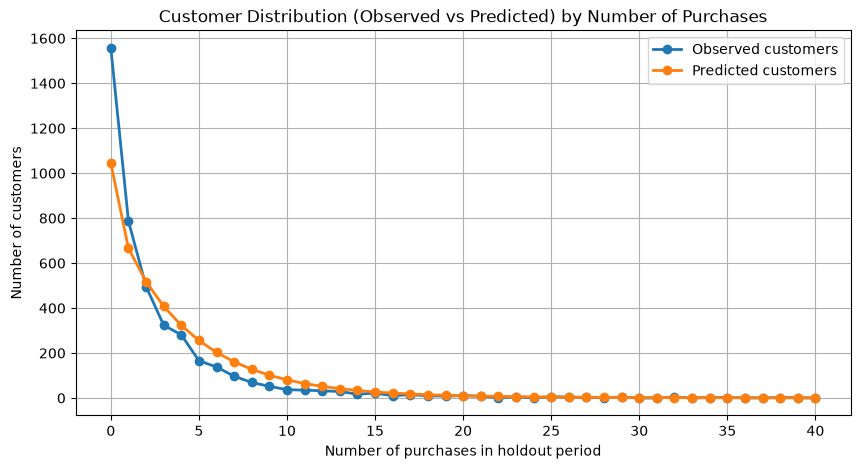

In [11]:
# observed purchases per customer in holdout
observed = df_holdout.groupby("Customer_ID")["order_id"].nunique()
evaluation["observed_purchases"] = evaluation["customer_id"].map(observed).fillna(0).astype(int)

# predicted and observed customer counts for 0..40 purchases in holdout
max_n = 40
n_vals = list(range(max_n + 1))

pred_counts = []
for n in n_vals:
    p_n = np.asarray(
        pareto_model.expected_purchase_probability(
            data=summary_cal,
            n_purchases=n,
            future_t=holdout_period
        )
    ).ravel()
    pred_counts.append(p_n.sum())

observed_counts = (
    evaluation["observed_purchases"]
    .value_counts()
    .reindex(n_vals, fill_value=0)
    .sort_index()
)

count_summary = pd.DataFrame({
    "n_purchases": n_vals,
    "predicted_customers": pred_counts,
    "observed_customers": observed_counts.values
})

plt.figure(figsize=(10, 5))
plt.plot(count_summary["n_purchases"], count_summary["observed_customers"], marker="o", linewidth=2, label="Observed customers")
plt.plot(count_summary["n_purchases"], count_summary["predicted_customers"], marker="o", linewidth=2, label="Predicted customers")
plt.xlabel("Number of purchases in holdout period")
plt.ylabel("Number of customers")
plt.title("Customer Distribution (Observed vs Predicted) by Number of Purchases")
plt.grid(True)
plt.legend()
plt.show()

<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Figure discussion — observed versus predicted purchase-count distribution.</em></strong></div>

For each $n=0,1,\ldots,40$, the predicted line is $\sum_i \Pr[X_i(H)=n \mid \mathcal{H}_i]$, the model's expected number of customers making exactly $n$ purchases during the holdout period. Overall, the model overpredicts purchase frequency, assigning too many customers to the higher purchase-count groups.

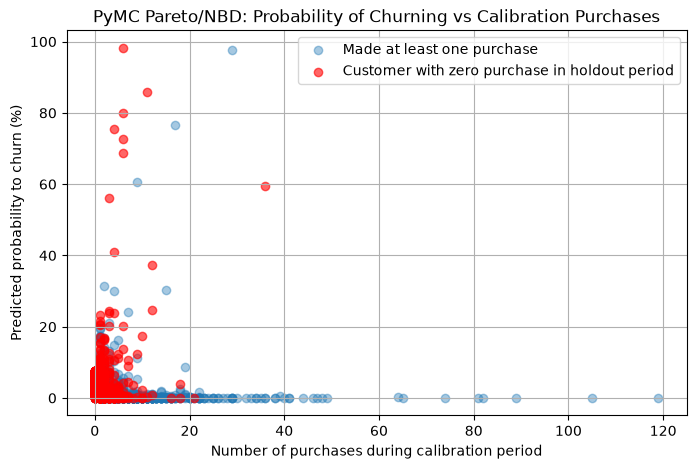

In [12]:
holdout_customers = set(df_holdout["Customer_ID"].unique())

evaluation["Observed_zero_purchase"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

plot_data = evaluation.dropna(subset=["p_alive"]).copy()

purchased = plot_data[plot_data["Observed_zero_purchase"] == False]
Observed_zero_purchase = plot_data[plot_data["Observed_zero_purchase"] == True]

plt.figure(figsize=(8, 5))

plt.scatter(
    purchased["frequency"],
    100-100*purchased["p_alive"],
    alpha=0.4,
    label="Made at least one purchase"
)

plt.scatter(
    Observed_zero_purchase["frequency"],
    100-100*Observed_zero_purchase["p_alive"],
    color="red",
    alpha=0.6,
    label="Customer with zero purchase in holdout period"
)

plt.xlabel("Number of purchases during calibration period")
plt.ylabel("Predicted probability to churn (%)")
plt.title("PyMC Pareto/NBD: Probability of Churning vs Calibration Purchases")
plt.grid(True)
plt.legend()
plt.show()

<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Figure discussion — predicted churn probability versus calibration frequency.</em></strong></div>

The scatter plot examines whether the model's risk estimates move in the expected direction as evidence accumulates. Each point represents a customer; the horizontal axis is calibration purchase frequency, and the vertical axis is the customer's predicted churn probability, $100\times[1-\Pr(\text{alive}\mid\mathcal{H}_i)]$. Red points represent customers who made no holdout purchase, while the other points represent customers who purchased at least once. Customers assigned higher churn probabilities are predominantly in the zero-purchase group, although substantial overlap remains between the two groups.

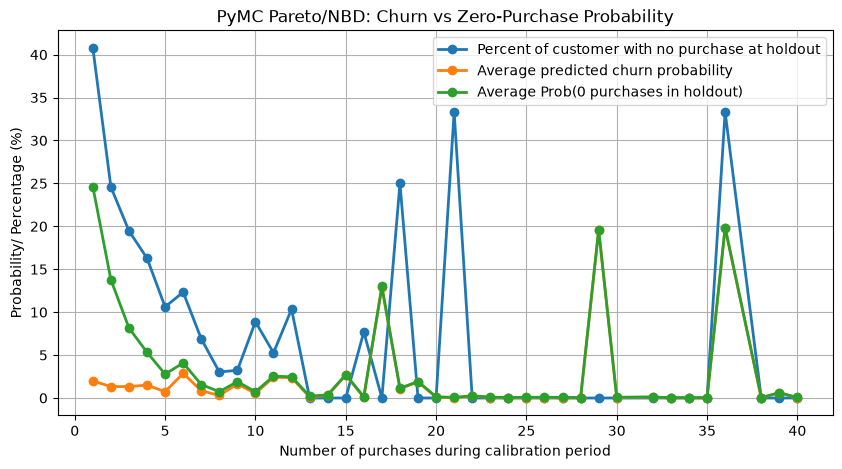

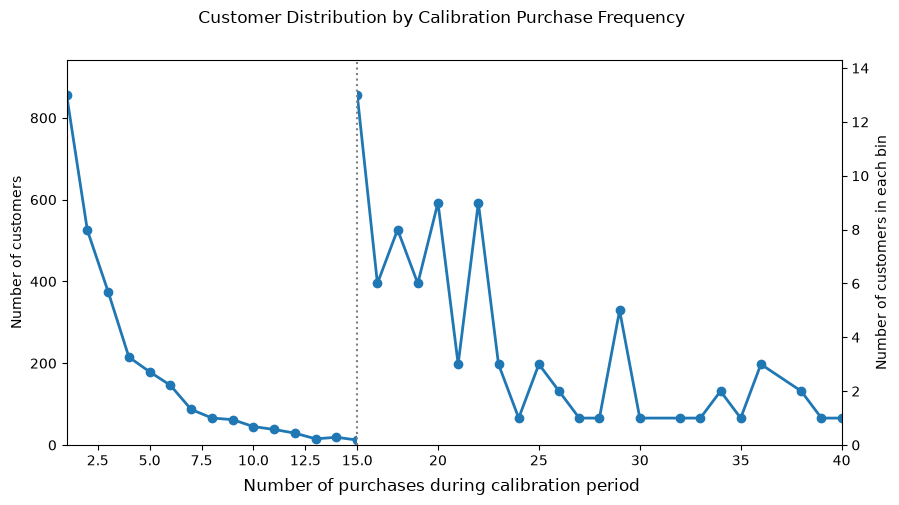

In [13]:
holdout_customers = set(df_holdout["Customer_ID"].unique())

evaluation["Observed_zero_purchase"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    pareto_model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    pareto_model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "Observed_zero_purchase"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]

freq_summary = (
    plot_data[
        (plot_data["frequency"] >= 1) &
        (plot_data["frequency"] <= 40)
    ]
    .groupby("frequency")
    .agg(
        Observed_zero_purchase_rate=("Observed_zero_purchase", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("Observed_zero_purchase", "size")
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(freq_summary["frequency"], 100*freq_summary["Observed_zero_purchase_rate"], marker="o", linewidth=2, label="Percent of customer with no purchase at holdout")
plt.plot(freq_summary["frequency"], 100*freq_summary["avg_pred_churn_prob"], marker="o", linewidth=2, label="Average predicted churn probability")
plt.plot(freq_summary["frequency"], 100*freq_summary["avg_p0"], marker="o", linewidth=2, label="Average Prob(0 purchases in holdout)")
plt.xlabel("Number of purchases during calibration period")
plt.ylabel("Probability/ Percentage (%)")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability")
plt.grid(True)
plt.legend()
plt.show()


#===================================================================
# Plotting Customer Distribution
#===================================================================

# Displays a clean, native full-width horizontal rule line
display(HTML("<hr>"))
print('\n')


split_freq = 15

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [15, 25]},
    sharex=False,
    sharey=False
)

left = freq_summary[freq_summary["frequency"] <= split_freq]
right = freq_summary[freq_summary["frequency"] > split_freq]

ax1.plot(left["frequency"], left["n_customers"], marker="o", linewidth=2)
ax2.plot(right["frequency"], right["n_customers"], marker="o", linewidth=2)

# x limits
ax1.set_xlim(1, 15)
ax2.set_xlim(16, 40)

# independent y limits
ax1.set_ylim(0, left["n_customers"].max() * 1.1)
ax2.set_ylim(0, right["n_customers"].max() * 1.1)

# remove touching spines
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

# left y-axis
ax1.yaxis.set_ticks_position("left")
ax1.yaxis.set_label_position("left")
ax1.set_ylabel("Number of customers")

# right y-axis
ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("Number of customers in each bin")


# dotted separator
ax1.axvline(
    x=15,
    color="gray",
    linestyle=":",
    linewidth=1.5
)

ax2.axvline(
    x=16,
    color="gray",
    linestyle=":",
    linewidth=1.5
)

# x labels
fig.supxlabel("Number of purchases during calibration period")

fig.suptitle("Customer Distribution by Calibration Purchase Frequency")

# panels touch each other
plt.subplots_adjust(wspace=0)

plt.show()

<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Figure discussion — how calibration frequency changes future-risk estimates.</em></strong></div>

The first panel revisits the apparently poor confusion-matrix result in a more appropriate way. The contrast with the threshold result is not a contradiction. To understand Pareto/NBD produces a probability, not a definitive statement that a particular customer will churn. A predicted churn probability of 10% means that, among ten similar customers, about one would be expected to churn on average; it does not identify which one. Consequently, the model can have very few correct individual classifications at a fixed 0.5 cutoff while still giving sensible probabilities for groups of customers. The close blue-green relationship is evidence for this group-level calibration, whereas the eight correct threshold classifications show that it should not be used as a precise individual churn label.

Finally, zero holdout purchases are not the same as permanent churn. Some customers remain active but have a long interval between two purchases and therefore make no purchase during this particular 369-day window. The green $p_0$ curve accounts for both possibilities—permanent dropout and an active customer who happens not to purchase—so it is the proper curve to compare with the blue observed zero-purchase rate. The remaining gaps and the sparse highest-frequency groups still warrant caution, but the figure strengthens the case that the model is useful for estimating aggregate purchase risk and ranking customers by that risk.

The blue line is the observed share of customers with no holdout purchase. The green line is $p_0$, the model's predicted probability of no purchase during the 369-day holdout, and the remaining line is the probability of permanent churn, $1-p_{alive}$. The key result is that the green curve follows the blue curve across the frequency groups. Customers with few earlier purchases have a high observed and predicted chance of making no later purchase; the risk falls as earlier purchasing becomes more frequent. This agreement shows that the model is capturing the broad pattern of future inactivity.

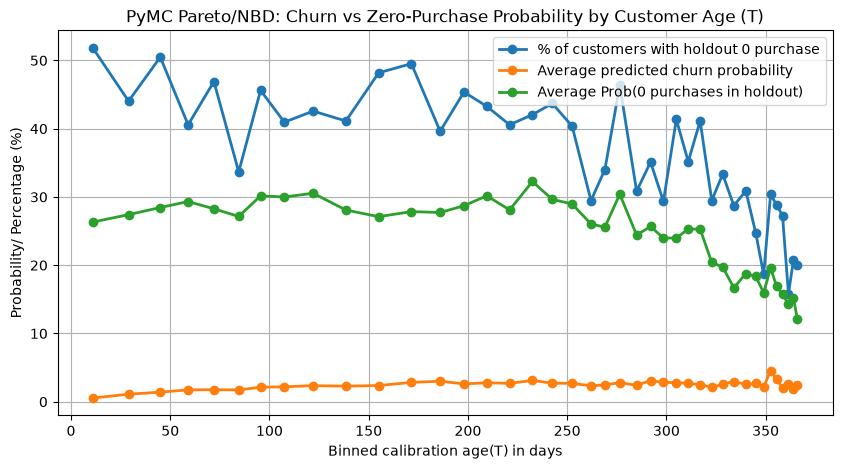

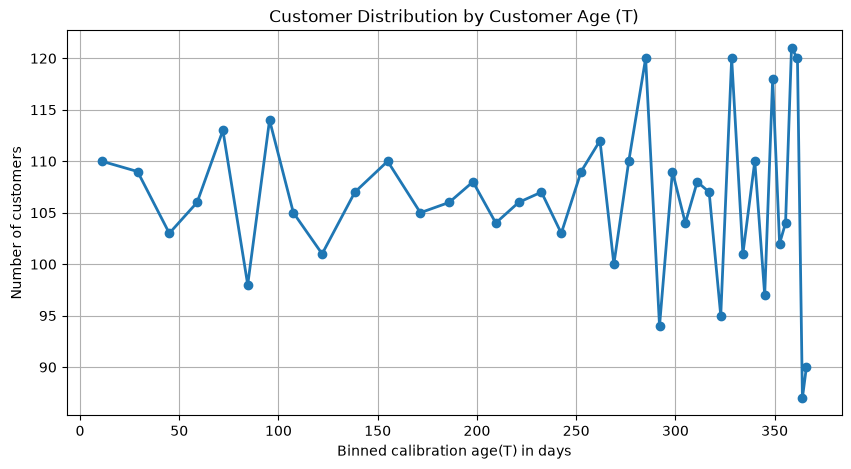

In [14]:
holdout_customers = set(df_holdout["Customer_ID"].unique())

evaluation["Observed_zero_purchase"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    pareto_model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    pareto_model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "Observed_zero_purchase", "T"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]

# 40 classes for T
plot_data["T_class"] = pd.qcut(
    plot_data["T"],
    q=40,
    duplicates="drop"
)

T_summary = (
    plot_data
    .groupby("T_class", observed=True)
    .agg(
        Observed_zero_purchase_rate=("Observed_zero_purchase", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("Observed_zero_purchase", "size")
    )
    .reset_index()
)

T_summary["T_mid"] = T_summary["T_class"].apply(lambda x: (x.left + x.right) / 2)
T_summary = T_summary.sort_values("T_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1: churn-related curves vs T
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    100*T_summary["Observed_zero_purchase_rate"],
    marker="o",
    linewidth=2,
    label="% of customers with holdout 0 purchase"
)

plt.plot(
    T_summary["T_mid"],
    100*T_summary["avg_pred_churn_prob"],
    marker="o",
    linewidth=2,
    label="Average predicted churn probability"
)

plt.plot(
    T_summary["T_mid"],
    100*T_summary["avg_p0"],
    marker="o",
    linewidth=2,
    label="Average Prob(0 purchases in holdout)"
)

plt.xlabel("Binned calibration age(T) in days")
plt.ylabel("Probability/ Percentage (%)")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability by Customer Age (T)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Figure 2: customer distribution by T class
# --------------------------------------------------
# Displays a clean, native full-width horizontal rule line
display(HTML("<hr>"))

plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    T_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Binned calibration age(T) in days")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Customer Age (T)")
plt.grid(True)
plt.show()

<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Figure discussion — customer age at calibration end ($T$).</em></strong></div>

Customer age, $T_i$, is the length of time between the first observed purchase and the calibration endpoint. A customer with one purchase and $T_i=20$ days is at a fundamentally different stage from a customer with one purchase and $T_i=300$ days. The former may simply be new, whereas the latter has had a long time in which to return.

The figure evaluates whether the model uses this exposure information plausibly. For comparable frequency and recency histories, a longer-aged customer with little recent activity should generally have a greater observed and predicted chance of zero purchasing, because the absence of repeat purchases has persisted over a longer interval. Conversely, a young customer should not be labelled as a high-risk dropout merely because their purchase history is short. Alignment of the observed no-purchase and $p_0$ curves across the central, well-populated age bins would therefore strengthen confidence that the model is separating lack of opportunity from lack of engagement.

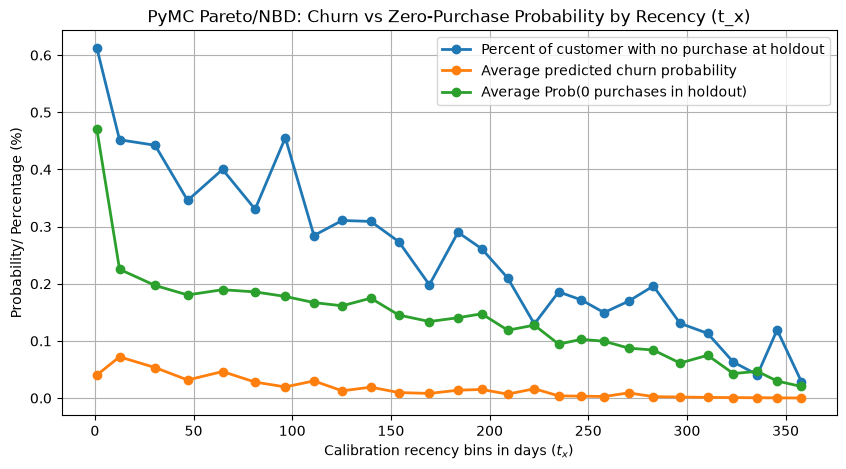

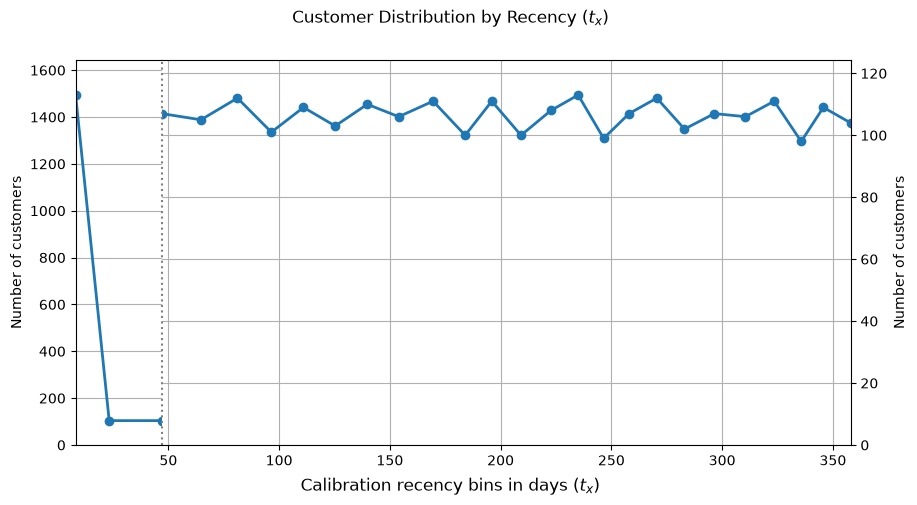

In [15]:
holdout_customers = set(df_holdout["Customer_ID"].unique())

evaluation["Observed_zero_purchase"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    pareto_model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    pareto_model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "Observed_zero_purchase", "recency"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]

# 40 classes for t_x (recency)
plot_data["tx_class"] = pd.qcut(
    plot_data["recency"],
    q=40,
    duplicates="drop"
)

tx_summary = (
    plot_data
    .groupby("tx_class", observed=True)
    .agg(
        Observed_zero_purchase_rate=("Observed_zero_purchase", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("Observed_zero_purchase", "size")
    )
    .reset_index()
)

tx_summary["tx_mid"] = tx_summary["tx_class"].apply(lambda x: (x.left + x.right) / 2)
tx_summary = tx_summary.sort_values("tx_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1: churn-related curves vs t_x
# --------------------------------------------------
# Displays a clean, native full-width horizontal rule line
display(HTML("<hr>"))

plt.figure(figsize=(10, 5))

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["Observed_zero_purchase_rate"],
    marker="o",
    linewidth=2,
    label="Percent of customer with no purchase at holdout"
)

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["avg_pred_churn_prob"],
    marker="o",
    linewidth=2,
    label="Average predicted churn probability"
)

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["avg_p0"],
    marker="o",
    linewidth=2,
    label="Average Prob(0 purchases in holdout)"
)

plt.xlabel("Calibration recency bins in days ($t_x$)")
plt.ylabel("Probability/ Percentage (%)")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability by Recency (t_x)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Figure 2: customer distribution by t_x
# --------------------------------------------------

# Displays a clean, native full-width horizontal rule line
display(HTML("<hr>"))

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [3, max(len(tx_summary)-3, 1)]},
    sharex=False,
    sharey=False
)

left = tx_summary.iloc[:3]
right = tx_summary.iloc[3:]

ax1.plot(left["tx_mid"], left["n_customers"], marker="o", linewidth=2)
ax2.plot(right["tx_mid"], right["n_customers"], marker="o", linewidth=2)

# x limits
ax1.set_xlim(left["tx_mid"].min(), left["tx_mid"].max())
ax2.set_xlim(right["tx_mid"].min(), right["tx_mid"].max())

# independent y limits
ax1.set_ylim(0, left["n_customers"].max() * 1.1)
ax2.set_ylim(0, right["n_customers"].max() * 1.1)

# remove touching spines
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

# y axes
ax1.yaxis.set_ticks_position("left")
ax1.yaxis.set_label_position("left")
ax1.set_ylabel("Number of customers")

ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("Number of customers")


# dotted separator
ax1.axvline(
    left["tx_mid"].max(),
    color="gray",
    linestyle=":",
    linewidth=1.5
)

ax2.axvline(
    right["tx_mid"].min(),
    color="gray",
    linestyle=":",
    linewidth=1.5
)


# Custom ticks every 50 units
xmin = int(np.floor(tx_summary["tx_mid"].min() / 50) * 50)
xmax = int(np.ceil(tx_summary["tx_mid"].max() / 50) * 50)

ticks = np.arange(xmin, xmax + 1, 50)

ax1.set_xticks([t for t in ticks if left["tx_mid"].min() <= t <= left["tx_mid"].max()])
ax2.set_xticks([t for t in ticks if right["tx_mid"].min() <= t <= right["tx_mid"].max()])

ax1.grid(True)
ax2.grid(True)

# x labels
fig.supxlabel("Calibration recency bins in days ($t_x$)")

fig.suptitle("Customer Distribution by Recency ($t_x$)")

plt.subplots_adjust(wspace=0)
plt.show()

<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Figure discussion — recency ($t_x$) and the fading signal of engagement.</em></strong></div>

Recency is the time of the customer's most recent calibration purchase. A customer who purchased near the end of calibration has a recent sign of engagement, whereas a customer whose last purchase was much earlier has a longer period of silence. The figure therefore tests whether the model's predictions fit the observed data: the blue observed no-purchase rate should be close to the green predicted $p_0$ rate within each recency group.

The fit is assessed by the distance between those two curves, not by whether the churn-probability curve is identical to the observed line. In the central recency groups, where there are many customers, the predicted no-purchase pattern follows the observed increase in inactivity as the last purchase becomes older. This supports the model's use of recency as a meaningful signal. Differences between the curves show the remaining calibration error: where green is below blue, the model is too optimistic about future purchasing; where it is above, it is too pessimistic. The figure thus supports the model's overall risk pattern while also showing that it is an estimate of probability, not an exact forecast for every individual customer.

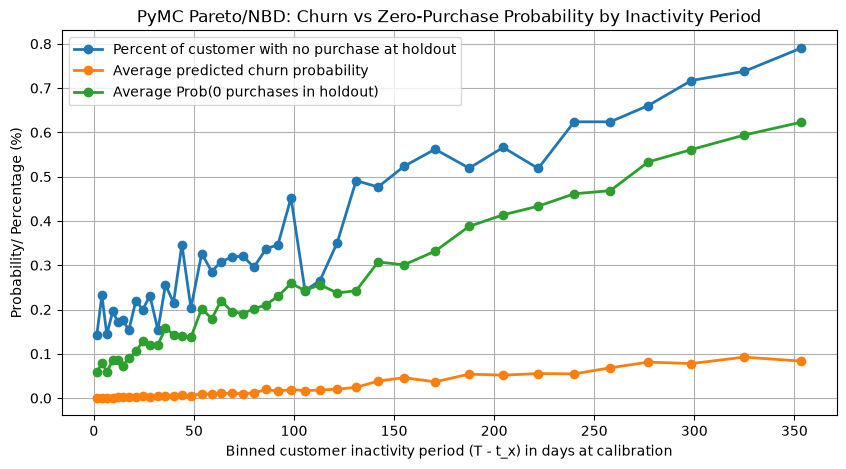

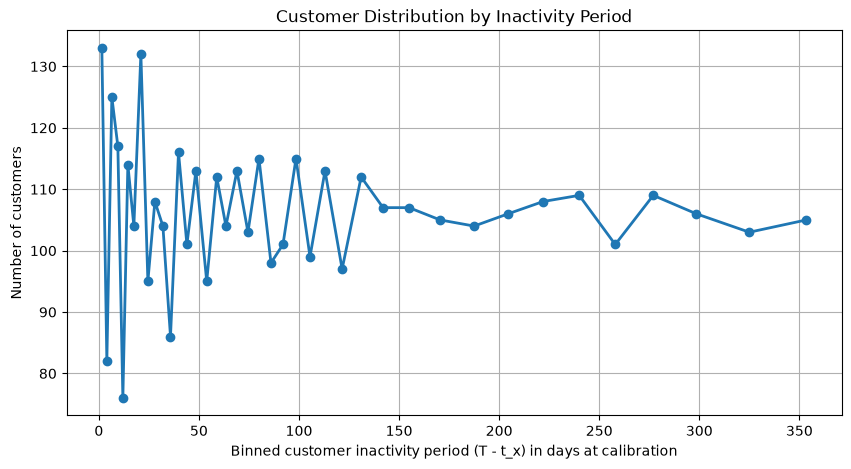

In [16]:
holdout_customers = set(df_holdout["Customer_ID"].unique())

evaluation["Observed_zero_purchase"] = (
    ~evaluation["customer_id"].isin(holdout_customers)
).astype(int)

evaluation["p_alive"] = np.asarray(
    pareto_model.expected_probability_alive(data=summary_cal)
).ravel()

evaluation["p0"] = np.asarray(
    pareto_model.expected_purchase_probability(
        data=summary_cal,
        n_purchases=0,
        future_t=holdout_period
    )
).ravel()

plot_data = evaluation.dropna(subset=["p_alive", "p0", "Observed_zero_purchase", "T", "recency"]).copy()
plot_data["pred_churn_prob"] = 1 - plot_data["p_alive"]
plot_data["inactivity"] = plot_data["T"] - plot_data["recency"]

# 40 classes for inactivity period
plot_data["inact_class"] = pd.qcut(
    plot_data["inactivity"],
    q=40,
    duplicates="drop"
)

inact_summary = (
    plot_data
    .groupby("inact_class", observed=True)
    .agg(
        Observed_zero_purchase_rate=("Observed_zero_purchase", "mean"),
        avg_pred_churn_prob=("pred_churn_prob", "mean"),
        avg_p0=("p0", "mean"),
        n_customers=("Observed_zero_purchase", "size")
    )
    .reset_index()
)

inact_summary["inact_mid"] = inact_summary["inact_class"].apply(
    lambda x: (x.left + x.right) / 2
)
inact_summary = inact_summary.sort_values("inact_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1: churn-related curves vs inactivity period
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["Observed_zero_purchase_rate"],
    marker="o",
    linewidth=2,
    label="Percent of customer with no purchase at holdout"
)

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["avg_pred_churn_prob"],
    marker="o",
    linewidth=2,
    label="Average predicted churn probability"
)

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["avg_p0"],
    marker="o",
    linewidth=2,
    label="Average Prob(0 purchases in holdout)"
)

plt.xlabel("Binned customer inactivity period (T - t_x) in days at calibration")
plt.ylabel("Probability/ Percentage (%)")
plt.title("PyMC Pareto/NBD: Churn vs Zero-Purchase Probability by Inactivity Period")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Figure 2: customer distribution by inactivity period
# --------------------------------------------------

# Displays a clean, native full-width horizontal rule line
display(HTML("<hr>"))

plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Binned customer inactivity period (T - t_x) in days at calibration")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Inactivity Period")
plt.grid(True)
plt.show()

## Number of Purchases in the Holdout Period: Predicted vs Observed

In [17]:
# Predict expected purchases during the holdout period
pred = pareto_model.expected_purchases(
    data=summary_cal,
    future_t=holdout_period
)

In [18]:
evaluation = summary_cal.copy()
evaluation["pred_purchases"] = np.asarray(pred).ravel()

# Observed purchases in the holdout period
observed = (
    df_holdout
    .groupby("Customer_ID")["order_id"]
    .nunique()
)

evaluation["observed_purchases"] = (
    evaluation["customer_id"]
    .map(observed)
    .fillna(0)
)

print("Total observed purchases   :", evaluation["observed_purchases"].sum())
print("Total predicted purchases:", evaluation["pred_purchases"].sum())

print("MAE :", mean_absolute_error(
    evaluation["observed_purchases"],
    evaluation["pred_purchases"]
))

print("RMSE:", np.sqrt(mean_squared_error(
    evaluation["observed_purchases"],
    evaluation["pred_purchases"]
)))

Total observed purchases   : 12493.0
Total predicted purchases: 17025.030943744714
MAE : 2.280226556031074
RMSE: 3.437930889237654


In [19]:
print("Pearson :", pearsonr(
    evaluation["observed_purchases"],
    evaluation["pred_purchases"]
)[0])

print("Spearman:", spearmanr(
    evaluation["observed_purchases"],
    evaluation["pred_purchases"]
)[0])

Pearson : 0.8378245661094923
Spearman: 0.5921866983942434


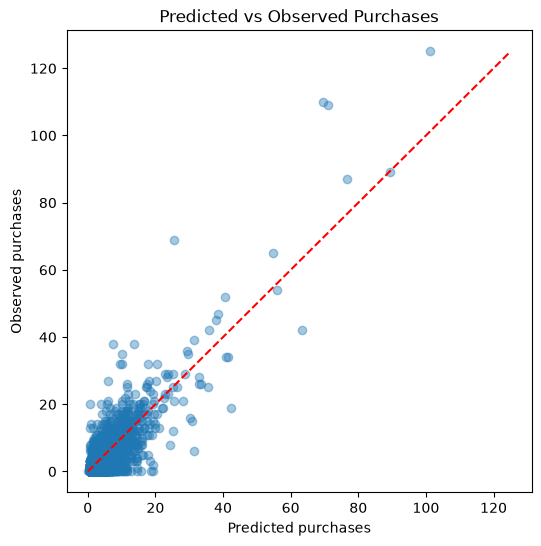

In [20]:
plt.figure(figsize=(6,6))

plt.scatter(
    evaluation["pred_purchases"],
    evaluation["observed_purchases"],
    alpha=0.4
)

m = max(
    evaluation["pred_purchases"].max(),
    evaluation["observed_purchases"].max()
)

plt.plot([0,m],[0,m],'r--')


plt.xlabel("Predicted purchases")
plt.ylabel("Observed purchases")
plt.title("Predicted vs Observed Purchases")

plt.show()

<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Figure discussion — customer-level predicted versus observed purchases.</em></strong></div>

Each point compares one customer's predicted and observed holdout purchases; the red dashed line represents perfect agreement. The upward pattern shows that customers predicted to purchase more generally do purchase more, consistent with Pearson $r=0.838$ and Spearman $\rho=0.592$. However, many points lie away from the diagonal, and the model predicts **17,025** purchases compared with **12,493** observed. The figure therefore supports the model's usefulness for ranking customers by future activity, while showing that its customer-level counts are imprecise and systematically high in aggregate.

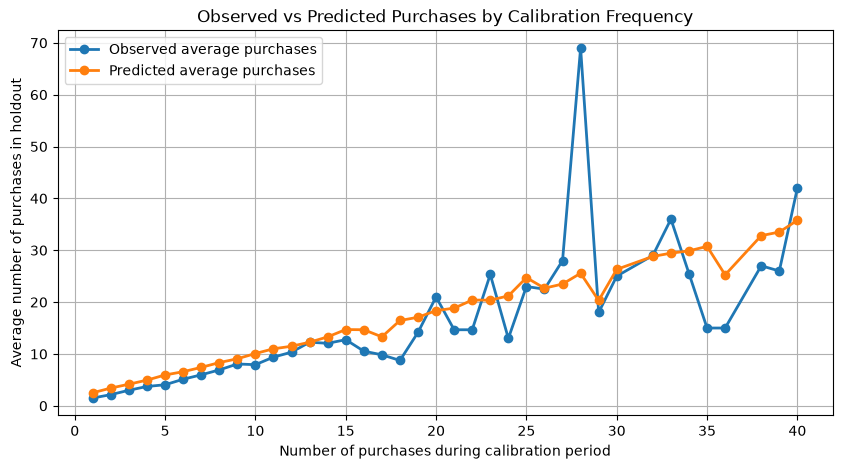

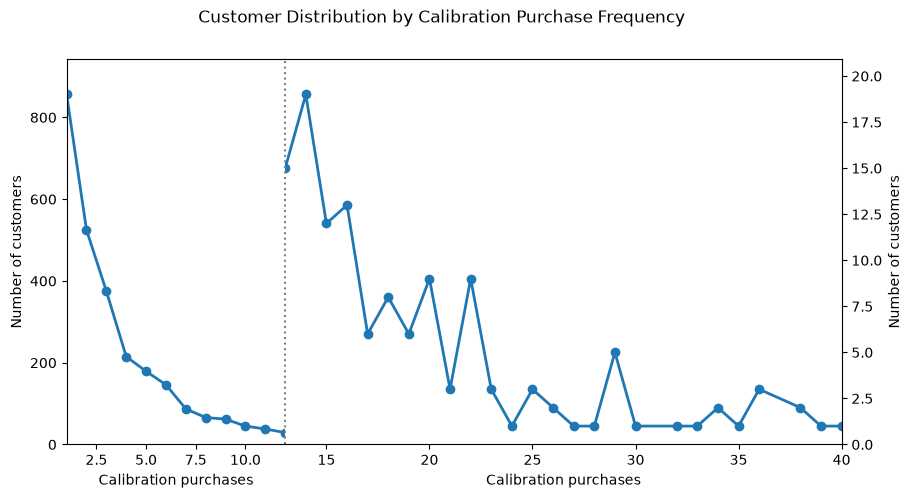

In [21]:
# predicted purchases for the holdout period
evaluation["pred_purchases"] = np.asarray(
    pareto_model.expected_purchases(data=summary_cal, future_t=holdout_period)
).ravel()

# observed purchases in holdout
observed = df_holdout.groupby("Customer_ID")["order_id"].nunique()
evaluation["observed_purchases"] = evaluation["customer_id"].map(observed).fillna(0)

plot_data = evaluation.dropna(subset=["pred_purchases", "observed_purchases"]).copy()

freq_summary = (
    plot_data[(plot_data["frequency"] >= 1) & (plot_data["frequency"] <= 40)]
    .groupby("frequency")
    .agg(
        observed_avg_purchases=("observed_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size"),
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(
    freq_summary["frequency"],
    freq_summary["observed_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Observed average purchases",
)
plt.plot(
    freq_summary["frequency"],
    freq_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases",
)
plt.xlabel("Number of purchases during calibration period")
plt.ylabel("Average number of purchases in holdout")
plt.title("Observed vs Predicted Purchases by Calibration Frequency")
plt.grid(True)
plt.legend()
plt.show()

#===================================================================
# Number of customer PLOT
#===================================================================

# Displays a clean, native full-width horizontal rule line
display(HTML("<hr>"))

print('\n')

x_split = 12

left_range = x_split - 1      
right_range = 40 - x_split    

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [left_range, right_range]},
    sharex=False,
    sharey=False
)

left = freq_summary[freq_summary["frequency"] <= x_split]
right = freq_summary[freq_summary["frequency"] > x_split]

ax1.plot(left["frequency"], left["n_customers"], marker="o", linewidth=2)
ax2.plot(right["frequency"], right["n_customers"], marker="o", linewidth=2)

# x limits
ax1.set_xlim(1, x_split)
ax2.set_xlim(x_split+1, 40)

# independent y limits
ax1.set_ylim(0, left["n_customers"].max() * 1.1)
ax2.set_ylim(0, right["n_customers"].max() * 1.1)

# remove touching spines
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

# left y-axis
ax1.yaxis.set_ticks_position("left")
ax1.yaxis.set_label_position("left")
ax1.set_ylabel("Number of customers")

# right y-axis
ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")
ax2.set_ylabel("Number of customers")

# x labels
ax1.set_xlabel("Calibration purchases")
ax2.set_xlabel("Calibration purchases")


# dotted separator
ax1.axvline(
    x=x_split,
    color="gray",
    linestyle=":",
    linewidth=1.5
)


ax2.axvline(
    x=x_split+1,
    color="gray",
    linestyle=":",
    linewidth=1.5
)


fig.suptitle("Customer Distribution by Calibration Purchase Frequency")

# panels touch each other
plt.subplots_adjust(wspace=0)

plt.show()

<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Figure discussion — observed versus predicted future purchases by calibration frequency.</em></strong></div>

Within each calibration-frequency group, the observed line is the average number of holdout purchases, and the predicted line is the average $E[X_i(H)\mid\mathcal{H}_i]$. The model should reproduce not only the fact that frequent historical buyers tend to buy more in the future, but also the *scale* of that relationship.

The numerical results reported immediately before this figure—not values read from the plotted lines—show **17,025** predicted holdout purchases versus **12,493** observed, or an overprediction of roughly **36%**. That same results cell calculates MAE (**2.28** orders), RMSE (**3.44** orders), Pearson $r=0.838$, and Spearman $\rho=0.592$ from the customer-level observed and predicted counts. The figure is the visual companion to those calculations: it shows whether the two average-count lines move together across calibration-frequency groups. Taken together, the evidence indicates that the model distinguishes low- from high-purchase customers reasonably well, but forecasts too many purchases in absolute terms.

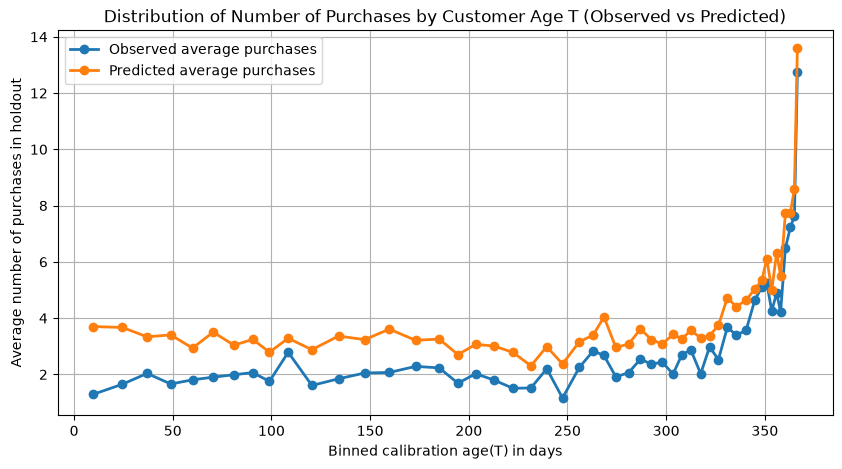

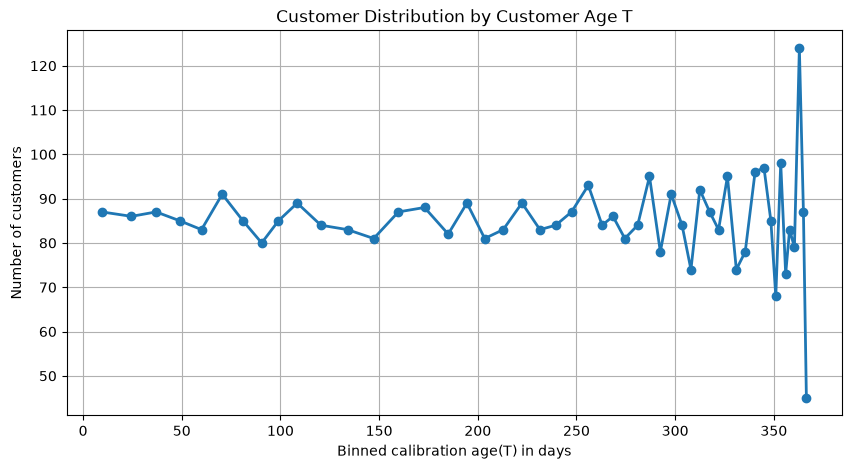

In [22]:
# --------------------------------------------------
# 1) Predict and attach observed purchases
# --------------------------------------------------
evaluation["pred_purchases"] = np.asarray(
    pareto_model.expected_purchases(data=summary_cal, future_t=holdout_period)
).ravel()

observed = df_holdout.groupby("Customer_ID")["order_id"].nunique()
evaluation["observed_purchases"] = evaluation["customer_id"].map(observed).fillna(0)

plot_data = evaluation.dropna(subset=["pred_purchases", "observed_purchases", "T"]).copy()

# --------------------------------------------------
# 2) Create about 50 classes for T using quantiles
#    T = customer age at end of calibration period
# --------------------------------------------------
plot_data["T_class"] = pd.qcut(
    plot_data["T"],
    q=50,
    duplicates="drop"
)

T_summary = (
    plot_data
    .groupby("T_class", observed=True)
    .agg(
        observed_avg_purchases=("observed_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size")
    )
    .reset_index()
)

# Use class midpoints for plotting on the x-axis
T_summary["T_mid"] = T_summary["T_class"].apply(
    lambda x: (x.left + x.right) / 2
)

T_summary = T_summary.sort_values("T_mid").reset_index(drop=True)

# --------------------------------------------------
# 3) Figure 1: Observed vs Predicted purchases by T class
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    T_summary["observed_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Observed average purchases"
)

plt.plot(
    T_summary["T_mid"],
    T_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases"
)

plt.xlabel("Binned calibration age(T) in days")
plt.ylabel("Average number of purchases in holdout")
plt.title("Distribution of Number of Purchases by Customer Age T (Observed vs Predicted)")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# 4) Figure 2: Customer distribution by T class
# --------------------------------------------------

# Displays a clean, native full-width horizontal rule line
display(HTML("<hr>"))

plt.figure(figsize=(10, 5))

plt.plot(
    T_summary["T_mid"],
    T_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Binned calibration age(T) in days")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Customer Age T")
plt.grid(True)
plt.show()

<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Figure discussion — predicted purchases across customer age ($T$).</em></strong></div>

The first figure compares observed and predicted average holdout purchases across the full range of customer age at calibration. The predicted line follows the broad movement of the observed line through the central age bins, indicating that the model uses exposure time reasonably well. It does not match every local fluctuation, so prediction quality is better for the overall pattern than for individual age classes. The customer-distribution figure provides context for those differences: deviations in less populated parts of the age range should be interpreted more cautiously because their observed averages are less stable.

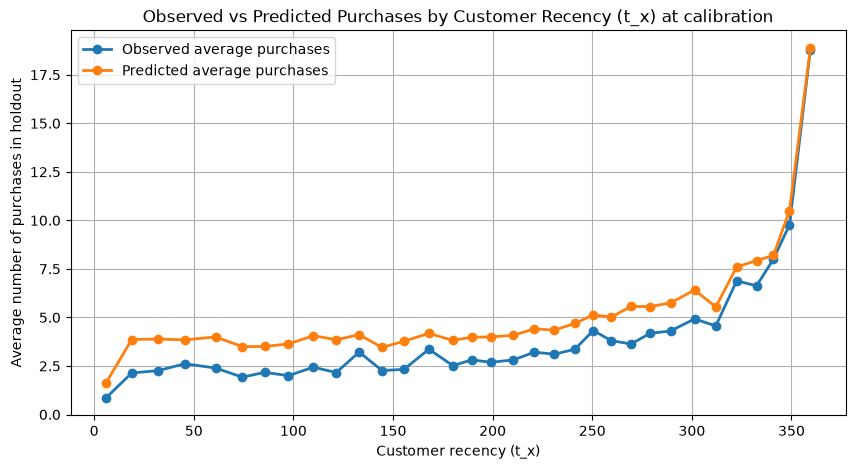

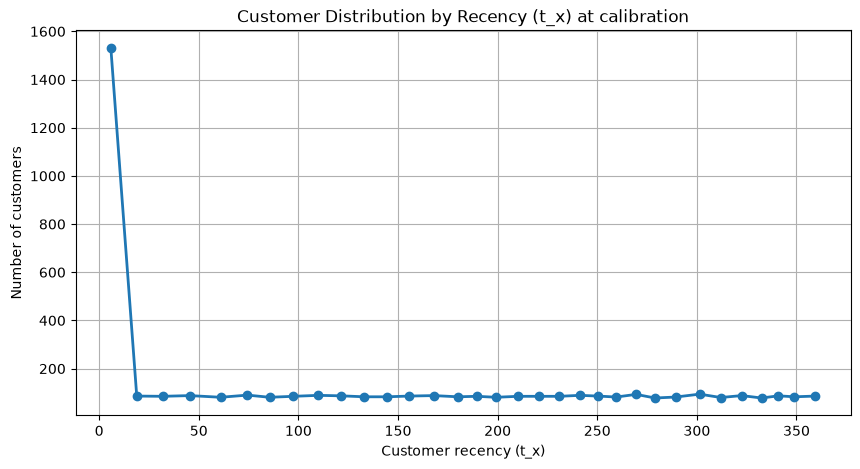

In [23]:
# --------------------------------------------------
# Create ~50 recency (t_x) classes
# --------------------------------------------------
plot_data = evaluation.dropna(
    subset=["pred_purchases", "observed_purchases", "recency"]
).copy()

plot_data["tx_class"] = pd.qcut(
    plot_data["recency"],
    q=50,
    duplicates="drop"
)

tx_summary = (
    plot_data
    .groupby("tx_class", observed=True)
    .agg(
        observed_avg_purchases=("observed_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size")
    )
    .reset_index()
)

tx_summary["tx_mid"] = tx_summary["tx_class"].apply(
    lambda x: (x.left + x.right) / 2
)

tx_summary = tx_summary.sort_values("tx_mid").reset_index(drop=True)

# --------------------------------------------------
# Figure 1
# --------------------------------------------------
plt.figure(figsize=(10,5))

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["observed_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Observed average purchases"
)

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases"
)

plt.xlabel("Customer recency (t_x)")
plt.ylabel("Average number of purchases in holdout")
plt.title("Observed vs Predicted Purchases by Customer Recency (t_x) at calibration")
plt.grid(True)
plt.legend()

plt.show()

# --------------------------------------------------
# Figure 2
# --------------------------------------------------

# Displays a clean, native full-width horizontal rule line
display(HTML("<hr>"))

plt.figure(figsize=(10,5))

plt.plot(
    tx_summary["tx_mid"],
    tx_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Customer recency (t_x)")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Recency (t_x) at calibration")
plt.grid(True)

plt.show()

<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Figure discussion — predicted purchases across recency ($t_x$).</em></strong></div>

Across the recency range, the predicted and observed lines move in the same general direction, showing that the model captures the relationship between a customer's most recent calibration purchase and future purchasing. Agreement is strongest across the central, well-populated recency bins. The model smooths over some short-range variation and diverges more in sparse parts of the range, so it describes the broad recency regime more reliably than every individual bin. The customer-distribution figure helps distinguish these sparse-bin deviations from systematic model error.

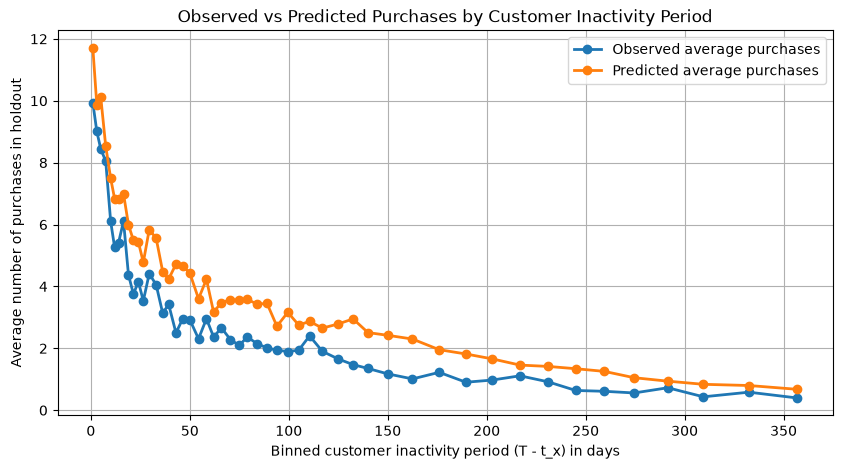

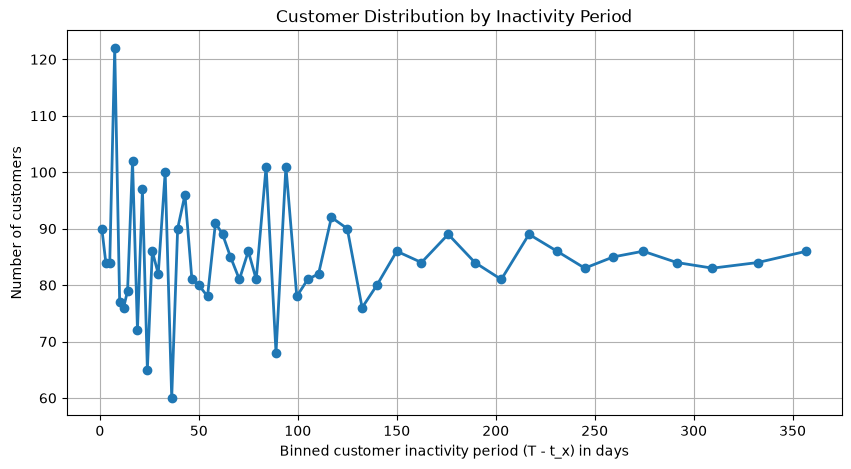

In [24]:
# customer inactivity period = T - t_x
plot_data = evaluation.dropna(
    subset=["pred_purchases", "observed_purchases", "T", "recency"]
).copy()

plot_data["inactivity"] = plot_data["T"] - plot_data["recency"]

# 50 quantile-based classes
plot_data["inactivity_class"] = pd.qcut(
    plot_data["inactivity"],
    q=50,
    duplicates="drop"
)

inact_summary = (
    plot_data
    .groupby("inactivity_class", observed=True)
    .agg(
        observed_avg_purchases=("observed_purchases", "mean"),
        pred_avg_purchases=("pred_purchases", "mean"),
        n_customers=("customer_id", "size")
    )
    .reset_index()
)

inact_summary["inact_mid"] = inact_summary["inactivity_class"].apply(
    lambda x: (x.left + x.right) / 2
)

inact_summary = inact_summary.sort_values("inact_mid").reset_index(drop=True)

# Figure 1: observed vs predicted purchases by inactivity period
plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["observed_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Observed average purchases"
)

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["pred_avg_purchases"],
    marker="o",
    linewidth=2,
    label="Predicted average purchases"
)

plt.xlabel("Binned customer inactivity period (T - t_x) in days")
plt.ylabel("Average number of purchases in holdout")
plt.title("Observed vs Predicted Purchases by Customer Inactivity Period")
plt.grid(True)
plt.legend()
plt.show()

#=========================================================
# Plotting Customer Distribution
#=========================================================

# Displays a clean, native full-width horizontal rule line
display(HTML("<hr>"))

# Figure 2: customer distribution by inactivity period
plt.figure(figsize=(10, 5))

plt.plot(
    inact_summary["inact_mid"],
    inact_summary["n_customers"],
    marker="o",
    linewidth=2
)

plt.xlabel("Binned customer inactivity period (T - t_x) in days")
plt.ylabel("Number of customers")
plt.title("Customer Distribution by Inactivity Period")
plt.grid(True)
plt.show()

<div style="font-size: 1.10em; color: #0f4c5c; margin-top: 0.6em;"><strong><em>Figure discussion — predicted purchases across inactivity periods ($T-t_x$).</em></strong></div>

The model reproduces the main decline in future purchases as the time since the customer's last calibration purchase increases. Predicted and observed averages are closest through the more densely populated inactivity ranges, supporting the model's use of prolonged silence as a negative activity signal. The lines do not coincide across every bin, particularly toward the edges of the parameter range, where group averages are more variable. Overall, the model captures the direction and relative ordering across inactivity regimes better than the exact purchase level in each regime.